# STAGE 7 — MULTI-OBJECTIVE HYPERPARAMETER OPTIMIZATION

## 1. Objective

Stage 7 extends the single-objective HPO experiment from Stage 6 into a multi-objective optimization framework.

Stage 6 optimized F1-score alone.

Stage 7 simultaneously optimizes:

1. F1-score
2. PR-AUC

The purpose is to investigate whether hyperparameter configurations that perform well for minority-class classification according to F1 also provide strong precision-recall performance across classification thresholds.

---

## 2. Dataset

The experiment uses the UCI Bank Marketing `bank-full.csv` dataset.

The target variable is:

`y`

Target encoding:

- `no` → 0
- `yes` → 1

The dataset is imbalanced, with approximately:

- 88.3% negative samples
- 11.7% positive samples

Therefore, accuracy alone is not considered an adequate primary optimization objective.

---

## 3. Models

Three model families were investigated:

1. Logistic Regression
2. Decision Tree
3. Random Forest

These models provide different levels of model complexity and different inductive biases.

Logistic Regression provides a linear baseline.

Decision Tree captures nonlinear decision rules.

Random Forest provides an ensemble of decision trees and can model more complex nonlinear relationships.

---

## 4. Preprocessing

Numerical features were standardized using StandardScaler.

Categorical features were transformed using OneHotEncoder with:

`handle_unknown="ignore"`

A ColumnTransformer was used to apply the appropriate transformation to each feature type.

Preprocessing was placed inside the model pipeline.

This prevents preprocessing information from leaking from validation data into the training process.

---

## 5. Cross-validation

Three-fold StratifiedKFold cross-validation was used.

Stratification preserves the approximate class distribution across folds.

The random state was fixed at 42 to support reproducibility.

---

## 6. Multi-objective optimization

Optuna was used for multi-objective hyperparameter optimization.

The two objectives were:

- maximize F1-score
- maximize PR-AUC

Each hyperparameter configuration was evaluated using the training portion of the dataset through stratified cross-validation.

The final test set remained untouched during optimization.

---

## 7. Why F1-score?

F1-score combines Precision and Recall.

This is important for the Bank Marketing problem because the positive class represents customers who subscribed to a term deposit and is the minority class.

Optimizing only accuracy could produce misleading results because a model can obtain high accuracy by primarily predicting the majority class.

---

## 8. Why PR-AUC?

PR-AUC summarizes the Precision-Recall relationship across different decision thresholds.

It provides information about positive-class performance that can be especially useful for imbalanced classification.

Average Precision from scikit-learn was used as the PR-AUC measure.

---

## 9. Pareto optimization

Multi-objective optimization does not necessarily produce one single best configuration.

A configuration is Pareto-optimal when another configuration cannot improve one objective without sacrificing another objective.

The resulting Pareto front therefore represents trade-offs between F1-score and PR-AUC.

This allows the research study to examine different useful operating points rather than forcing one metric to dominate the optimization process.

---

## 10. Relationship with Stage 6

Stage 6:

- Single-objective HPO
- F1-score as objective

Stage 7:

- Multi-objective HPO
- F1-score and PR-AUC as objectives

This comparison allows the study to investigate whether multi-objective optimization identifies different hyperparameter configurations from single-objective F1 optimization.

---

## 11. Research significance

Stage 7 strengthens the research methodology because imbalanced classification performance is not represented by one metric alone.

The experiment investigates the trade-off between:

- minority-class Precision/Recall balance
- positive-class ranking quality across thresholds

The Pareto front provides a transparent way of presenting these trade-offs.

---

## 12. Important limitation

Multi-objective optimization does not prove that one Pareto configuration is universally superior.

The final configuration should be selected according to the intended application objective.

For example, a campaign that prioritizes identifying as many potential subscribers as possible may place greater importance on Recall, while another application may place greater importance on Precision.

Therefore, Stage 7 reports the Pareto solutions rather than declaring a universal winner.

---

## 13. Reproducibility

Random state 42 was used for:

- train/test split
- cross-validation
- model training where applicable

The Optuna trial histories and Pareto results were saved to the results directory.

---

## 14. Output files

The experiment produces:

`results/metrics/multiobjective_pareto_results.csv`

`results/hpo/logistic_multiobjective_trials.csv`

`results/hpo/decision_tree_multiobjective_trials.csv`

`results/hpo/random_forest_multiobjective_trials.csv`

These files contain the optimization results required for later analysis.

---

## 15. Connection to later stages

Stage 7 provides optimized multi-objective model configurations.

These results will be used together with later experiments involving:

- threshold optimization
- robustness analysis
- explainability
- explanation stability

The final research conclusions should be based on the combined evidence from these stages rather than on one optimization experiment alone.

In [1]:
import os
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import optuna
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

print("Optuna version:", optuna.__version__)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Optuna version: 5.0.0
Pandas version: 3.0.6
NumPy version: 2.4.6


In [2]:
data_path = "../data/raw/bank-full.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,18,student,single,primary,no,1944,no,no,telephone,10,aug,122,3,-1,0,unknown,no
1,18,student,single,unknown,no,108,no,no,cellular,10,aug,167,1,-1,0,unknown,yes
2,18,student,single,primary,no,608,no,no,cellular,12,aug,267,1,-1,0,unknown,yes
3,18,student,single,unknown,no,35,no,no,telephone,21,aug,104,2,-1,0,unknown,no
4,18,student,single,secondary,no,5,no,no,cellular,24,aug,143,2,-1,0,unknown,no


In [3]:
X = df.drop(columns=["y"]).copy()

y = df["y"].map({
    "no": 0,
    "yes": 1
})

if y.isna().any():
    raise ValueError("Target encoding produced missing values.")

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Features shape: (45211, 16)
Target shape: (45211,)

Target distribution:
y
0    39922
1     5289
Name: count, dtype: int64

Target percentage:
y
0    88.3
1    11.7
Name: proportion, dtype: float64


In [4]:
numerical_columns = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = X.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical features:")
print(numerical_columns)

print("\nCategorical features:")
print(categorical_columns)

print("\nNumber of numerical features:",
      len(numerical_columns))

print("Number of categorical features:",
      len(categorical_columns))

Numerical features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Number of numerical features: 7
Number of categorical features: 9


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (36168, 16)
Testing data: (9043, 16)

Training target distribution:
y
0    31937
1     4231
Name: count, dtype: int64

Testing target distribution:
y
0    7985
1    1058
Name: count, dtype: int64


In [6]:
numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_columns
        ),
        (
            "cat",
            categorical_transformer,
            categorical_columns
        )
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [7]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("Cross-validation:")
print(cv)

print("\nNumber of folds:", cv.n_splits)
print("Shuffle:", cv.shuffle)
print("Random state:", cv.random_state)

Cross-validation:
StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

Number of folds: 3
Shuffle: True
Random state: 42


# Stage 7 — Multi-Objective Hyperparameter Optimization

## 1. What is the purpose of Stage 7?

Stage 6 used single-objective Hyperparameter Optimization (HPO).

The objective in Stage 6 was:

> Maximize F1-score.

Stage 7 extends this approach by optimizing two objectives simultaneously:

1. F1-score
2. PR-AUC

This is called Multi-Objective Hyperparameter Optimization (MO-HPO).

---

## 2. Why do we need multiple objectives?

A machine-learning model can perform well according to one metric while performing differently according to another metric.

For example:

- A model may have strong F1-score.
- Another model may have slightly lower F1-score but better PR-AUC.

Instead of forcing the experiment to select one metric immediately, multi-objective optimization allows us to study the trade-off between the objectives.

---

## 3. Objective 1 — F1-score

F1-score combines Precision and Recall.

It is especially useful when the minority class is important.

For our dataset:

- Class 0 = customer did not subscribe
- Class 1 = customer subscribed

The positive class is the minority class.

Therefore F1-score is useful because it considers both:

- How many predicted positive customers were actually positive.
- How many actual positive customers were successfully detected.

---

## 4. Objective 2 — PR-AUC

PR-AUC means Area Under the Precision-Recall Curve.

It evaluates the relationship between:

- Precision
- Recall

across different classification thresholds.

PR-AUC is particularly useful for imbalanced classification because it focuses on the positive class and the precision-recall trade-off.

In scikit-learn, Average Precision is commonly used as a summary of the precision-recall curve.

---

## 5. What is Multi-Objective HPO?

Instead of:

Hyperparameters → maximize one metric

we perform:

Hyperparameters → maximize F1 AND maximize PR-AUC

There may not be one configuration that is best for both objectives.

Therefore, we identify configurations that form a Pareto front.

---

## 6. What is a Pareto-optimal solution?

A configuration is Pareto-optimal when another configuration cannot improve one objective without sacrificing another objective.

For example:

Model A:
- F1 = 0.61
- PR-AUC = 0.60

Model B:
- F1 = 0.60
- PR-AUC = 0.64

Neither model is automatically better according to both objectives.

This is the type of trade-off that Stage 7 investigates.

---

## 7. Leakage prevention

The test dataset remains completely untouched during optimization.

The workflow is:

Training data
↓
3-fold stratified cross-validation
↓
Preprocessing fitted inside each training fold
↓
Model training
↓
Validation prediction
↓
F1 and PR-AUC calculation

The final test set is used only after the optimization stage.

---

## 8. Relationship with Stage 6

Stage 6:
- Single objective
- F1 optimization

Stage 7:
- Multiple objectives
- F1 + PR-AUC optimization

This allows the research study to investigate whether optimizing multiple imbalance-aware objectives produces different hyperparameter configurations from optimizing F1 alone.

---

## 9. Important interpretation

Stage 7 does not automatically produce one universally best model.

Instead, it provides a set of Pareto-optimal configurations.

The final selection should therefore be based on the research objective and documented trade-offs rather than simply choosing a configuration because it has the highest value on one metric.

In [8]:
os.makedirs("../results/hpo", exist_ok=True)
os.makedirs("../results/metrics", exist_ok=True)
os.makedirs("../results/plots", exist_ok=True)

print("Stage 7 output directories are ready.")

Stage 7 output directories are ready.


In [9]:
def evaluate_multiobjective_cv(model):
    f1_scores = []
    pr_auc_scores = []

    for train_idx, valid_idx in cv.split(X_train, y_train):

        X_fold_train = X_train.iloc[train_idx]
        X_fold_valid = X_train.iloc[valid_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_valid = y_train.iloc[valid_idx]

        model.fit(
            X_fold_train,
            y_fold_train
        )

        y_pred = model.predict(
            X_fold_valid
        )

        y_proba = model.predict_proba(
            X_fold_valid
        )[:, 1]

        fold_f1 = f1_score(
            y_fold_valid,
            y_pred,
            zero_division=0
        )

        fold_pr_auc = average_precision_score(
            y_fold_valid,
            y_proba
        )

        f1_scores.append(fold_f1)
        pr_auc_scores.append(fold_pr_auc)

    return (
        np.mean(f1_scores),
        np.mean(pr_auc_scores)
    )

In [10]:
test_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

test_f1, test_pr_auc = evaluate_multiobjective_cv(
    test_model
)

print("Test evaluation completed.")

print("\nCross-validation F1:",
      round(test_f1, 4))

print("Cross-validation PR-AUC:",
      round(test_pr_auc, 4))

Test evaluation completed.

Cross-validation F1: 0.449
Cross-validation PR-AUC: 0.5496


In [11]:
def logistic_multiobjective(trial):

    C = trial.suggest_float(
        "C",
        1e-3,
        10.0,
        log=True
    )

    class_weight_option = trial.suggest_categorical(
        "class_weight",
        [None, "balanced"]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LogisticRegression(
                    C=C,
                    class_weight=class_weight_option,
                    max_iter=1000,
                    random_state=42
                )
            )
        ]
    )

    f1, pr_auc = evaluate_multiobjective_cv(
        model
    )

    return f1, pr_auc

In [12]:
logistic_mo_study = optuna.create_study(
    directions=["maximize", "maximize"],
    study_name="logistic_regression_multiobjective_hpo"
)

print("Logistic Regression multi-objective study created.")

[I 2026-09-20 13:38:51,420] A new study created in memory with name: logistic_regression_multiobjective_hpo


Logistic Regression multi-objective study created.


In [13]:
logistic_mo_study.optimize(
    logistic_multiobjective,
    n_trials=20,
    show_progress_bar=True
)

print("\nLogistic Regression multi-objective optimization completed.")
print("Number of trials:",
      len(logistic_mo_study.trials))

  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-20 13:38:59,411] Trial 0 finished with values: [0.4493957628782809, 0.5496954805862487] and parameters: {'C': 2.496127494130903, 'class_weight': None}.
[I 2026-09-20 13:38:59,966] Trial 1 finished with values: [0.5416037509988734, 0.5372842184874639] and parameters: {'C': 0.021384992723627597, 'class_weight': 'balanced'}.
[I 2026-09-20 13:39:00,597] Trial 2 finished with values: [0.4500711169487854, 0.5497277380216339] and parameters: {'C': 6.042817315058874, 'class_weight': None}.
[I 2026-09-20 13:39:01,384] Trial 3 finished with values: [0.40984223611066817, 0.5417509671826019] and parameters: {'C': 0.018295481850548745, 'class_weight': None}.
[I 2026-09-20 13:39:02,062] Trial 4 finished with values: [0.5421588038167302, 0.5388989570861069] and parameters: {'C': 0.028911781114091695, 'class_weight': 'balanced'}.
[I 2026-09-20 13:39:02,723] Trial 5 finished with values: [0.3436640131651698, 0.5269095467525183] and parameters: {'C': 0.005546046199325927, 'class_weight': None

In [14]:
print("=" * 80)
print("LOGISTIC REGRESSION — PARETO FRONT")
print("=" * 80)

print("\nNumber of Pareto-optimal trials:",
      len(logistic_mo_study.best_trials))

for trial in logistic_mo_study.best_trials:

    print("\nTrial:", trial.number)

    print("F1:",
          round(trial.values[0], 6))

    print("PR-AUC:",
          round(trial.values[1], 6))

    print("Parameters:")
    print(trial.params)

LOGISTIC REGRESSION — PARETO FRONT

Number of Pareto-optimal trials: 4

Trial: 2
F1: 0.450071
PR-AUC: 0.549728
Parameters:
{'C': 6.042817315058874, 'class_weight': None}

Trial: 6
F1: 0.547662
PR-AUC: 0.543986
Parameters:
{'C': 2.444972144868084, 'class_weight': 'balanced'}

Trial: 7
F1: 0.547517
PR-AUC: 0.544002
Parameters:
{'C': 5.847534732674548, 'class_weight': 'balanced'}

Trial: 13
F1: 0.450142
PR-AUC: 0.549706
Parameters:
{'C': 9.870614746380534, 'class_weight': None}


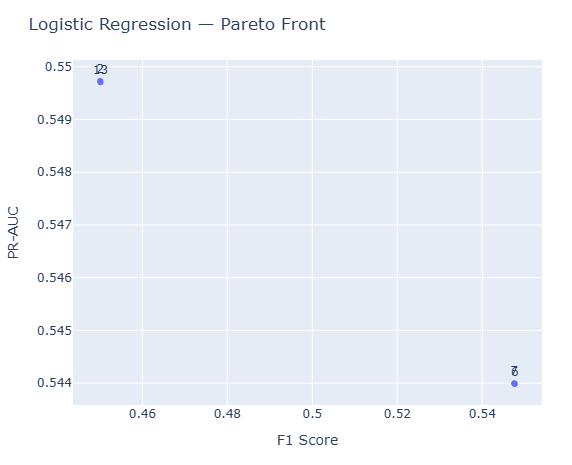

In [15]:
logistic_pareto_data = pd.DataFrame(
    [
        {
            "trial": trial.number,
            "F1": trial.values[0],
            "PR_AUC": trial.values[1]
        }
        for trial in logistic_mo_study.best_trials
    ]
)

fig = px.scatter(
    logistic_pareto_data,
    x="F1",
    y="PR_AUC",
    text="trial",
    title="Logistic Regression — Pareto Front",
    labels={
        "F1": "F1 Score",
        "PR_AUC": "PR-AUC",
        "trial": "Trial"
    }
)

fig.update_traces(
    textposition="top center"
)

fig.update_layout(
    width=700,
    height=450,
    margin=dict(
        l=60,
        r=30,
        t=60,
        b=60
    )
)

fig.show()

In [16]:
def tree_multiobjective(trial):

    max_depth = trial.suggest_int(
        "max_depth",
        3,
        30
    )

    min_samples_split = trial.suggest_int(
        "min_samples_split",
        2,
        20
    )

    min_samples_leaf = trial.suggest_int(
        "min_samples_leaf",
        1,
        10
    )

    max_features = trial.suggest_categorical(
        "max_features",
        [None, "sqrt", "log2"]
    )

    criterion = trial.suggest_categorical(
        "criterion",
        ["gini", "entropy", "log_loss"]
    )

    class_weight_option = trial.suggest_categorical(
        "class_weight",
        [None, "balanced"]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                DecisionTreeClassifier(
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    criterion=criterion,
                    class_weight=class_weight_option,
                    random_state=42
                )
            )
        ]
    )

    f1, pr_auc = evaluate_multiobjective_cv(
        model
    )

    return f1, pr_auc

In [17]:
tree_mo_study = optuna.create_study(
    directions=["maximize", "maximize"],
    study_name="decision_tree_multiobjective_hpo"
)

print("Decision Tree multi-objective study created.")

[I 2026-09-20 13:40:07,951] A new study created in memory with name: decision_tree_multiobjective_hpo


Decision Tree multi-objective study created.


In [18]:
tree_mo_study.optimize(
    tree_multiobjective,
    n_trials=20,
    show_progress_bar=True
)

print("\nDecision Tree multi-objective optimization completed.")
print("Number of trials:",
      len(tree_mo_study.trials))

  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-20 13:40:16,488] Trial 0 finished with values: [0.4824793741803941, 0.4618775100549184] and parameters: {'max_depth': 21, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': None, 'criterion': 'gini', 'class_weight': None}.
[I 2026-09-20 13:40:16,985] Trial 1 finished with values: [0.42320206516493486, 0.351451034547744] and parameters: {'max_depth': 27, 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'gini', 'class_weight': None}.
[I 2026-09-20 13:40:17,599] Trial 2 finished with values: [0.4786608004678825, 0.44864524833706815] and parameters: {'max_depth': 26, 'min_samples_split': 13, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'log_loss', 'class_weight': 'balanced'}.
[I 2026-09-20 13:40:18,255] Trial 3 finished with values: [0.4822255566323677, 0.493445733584232] and parameters: {'max_depth': 6, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': None, 'criterion': 'log_loss', 'class_weight': No

In [19]:
print("=" * 80)
print("DECISION TREE — PARETO FRONT")
print("=" * 80)

print("\nNumber of Pareto-optimal trials:",
      len(tree_mo_study.best_trials))

for trial in tree_mo_study.best_trials:

    print("\nTrial:", trial.number)

    print("F1:",
          round(trial.values[0], 6))

    print("PR-AUC:",
          round(trial.values[1], 6))

    print("Parameters:")
    print(trial.params)

DECISION TREE — PARETO FRONT

Number of Pareto-optimal trials: 4

Trial: 3
F1: 0.482226
PR-AUC: 0.493446
Parameters:
{'max_depth': 6, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': None, 'criterion': 'log_loss', 'class_weight': None}

Trial: 12
F1: 0.478444
PR-AUC: 0.512982
Parameters:
{'max_depth': 12, 'min_samples_split': 17, 'min_samples_leaf': 9, 'max_features': None, 'criterion': 'log_loss', 'class_weight': None}

Trial: 18
F1: 0.528489
PR-AUC: 0.488691
Parameters:
{'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_features': None, 'criterion': 'entropy', 'class_weight': 'balanced'}

Trial: 19
F1: 0.5307
PR-AUC: 0.467458
Parameters:
{'max_depth': 23, 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_features': None, 'criterion': 'entropy', 'class_weight': 'balanced'}


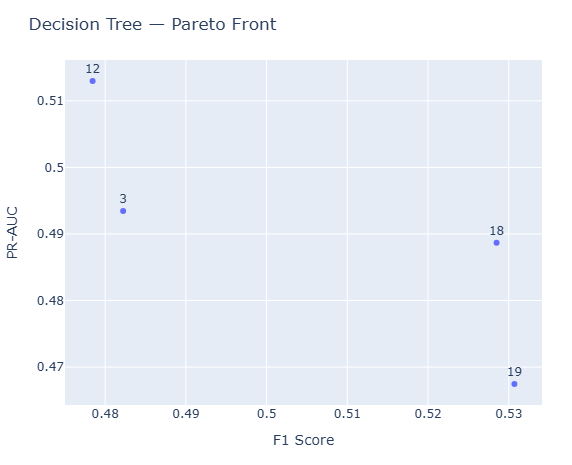

In [20]:
tree_pareto_data = pd.DataFrame(
    [
        {
            "trial": trial.number,
            "F1": trial.values[0],
            "PR_AUC": trial.values[1]
        }
        for trial in tree_mo_study.best_trials
    ]
)

fig = px.scatter(
    tree_pareto_data,
    x="F1",
    y="PR_AUC",
    text="trial",
    title="Decision Tree — Pareto Front",
    labels={
        "F1": "F1 Score",
        "PR_AUC": "PR-AUC",
        "trial": "Trial"
    }
)

fig.update_traces(
    textposition="top center"
)

fig.update_layout(
    width=700,
    height=450,
    margin=dict(
        l=60,
        r=30,
        t=60,
        b=60
    )
)

fig.show()

In [21]:
def random_forest_multiobjective(trial):

    n_estimators = trial.suggest_int(
        "n_estimators",
        100,
        500,
        step=50
    )

    max_depth = trial.suggest_int(
        "max_depth",
        5,
        30
    )

    min_samples_split = trial.suggest_int(
        "min_samples_split",
        2,
        20
    )

    min_samples_leaf = trial.suggest_int(
        "min_samples_leaf",
        1,
        10
    )

    max_features = trial.suggest_categorical(
        "max_features",
        ["sqrt", "log2", None]
    )

    class_weight_option = trial.suggest_categorical(
        "class_weight",
        [None, "balanced"]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    class_weight=class_weight_option,
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )

    f1, pr_auc = evaluate_multiobjective_cv(
        model
    )

    return f1, pr_auc

In [22]:
rf_mo_study = optuna.create_study(
    directions=["maximize", "maximize"],
    study_name="random_forest_multiobjective_hpo"
)

print("Random Forest multi-objective study created.")

[I 2026-09-20 13:40:49,563] A new study created in memory with name: random_forest_multiobjective_hpo


Random Forest multi-objective study created.


In [23]:
rf_mo_study.optimize(
    random_forest_multiobjective,
    n_trials=20,
    show_progress_bar=True
)

print("\nRandom Forest multi-objective optimization completed.")
print("Number of trials:",
      len(rf_mo_study.trials))

  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-20 13:40:59,351] Trial 0 finished with values: [0.5469201663656481, 0.5748370803177222] and parameters: {'n_estimators': 200, 'max_depth': 9, 'min_samples_split': 4, 'min_samples_leaf': 9, 'max_features': None, 'class_weight': 'balanced'}.
[I 2026-09-20 13:41:06,689] Trial 1 finished with values: [0.4991758213074389, 0.5867259147850107] and parameters: {'n_estimators': 350, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 9, 'max_features': None, 'class_weight': None}.
[I 2026-09-20 13:41:12,413] Trial 2 finished with values: [0.5715351865312408, 0.5883751962554614] and parameters: {'n_estimators': 250, 'max_depth': 12, 'min_samples_split': 18, 'min_samples_leaf': 7, 'max_features': None, 'class_weight': 'balanced'}.
[I 2026-09-20 13:41:28,432] Trial 3 finished with values: [0.5272663656797428, 0.6010661628138981] and parameters: {'n_estimators': 400, 'max_depth': 27, 'min_samples_split': 15, 'min_samples_leaf': 7, 'max_features': None, 'class_weight': None}.
[I 2

In [24]:
print("=" * 80)
print("RANDOM FOREST — PARETO FRONT")
print("=" * 80)

print("\nNumber of Pareto-optimal trials:",
      len(rf_mo_study.best_trials))

for trial in rf_mo_study.best_trials:

    print("\nTrial:", trial.number)

    print("F1:",
          round(trial.values[0], 6))

    print("PR-AUC:",
          round(trial.values[1], 6))

    print("Parameters:")
    print(trial.params)

RANDOM FOREST — PARETO FRONT

Number of Pareto-optimal trials: 2

Trial: 15
F1: 0.473849
PR-AUC: 0.615637
Parameters:
{'n_estimators': 400, 'max_depth': 26, 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': None}

Trial: 17
F1: 0.601403
PR-AUC: 0.605014
Parameters:
{'n_estimators': 400, 'max_depth': 29, 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': 'balanced'}


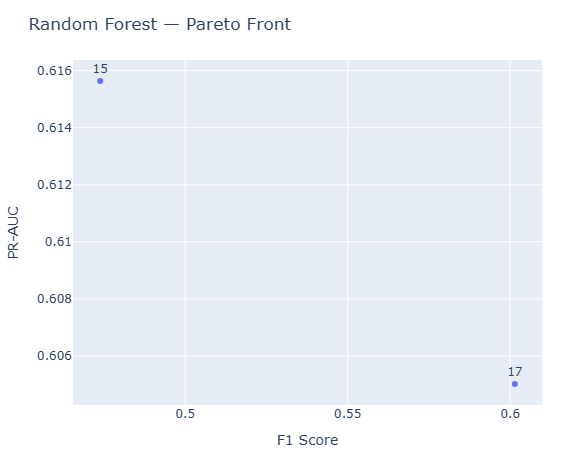

In [25]:
rf_pareto_data = pd.DataFrame(
    [
        {
            "trial": trial.number,
            "F1": trial.values[0],
            "PR_AUC": trial.values[1]
        }
        for trial in rf_mo_study.best_trials
    ]
)

fig = px.scatter(
    rf_pareto_data,
    x="F1",
    y="PR_AUC",
    text="trial",
    title="Random Forest — Pareto Front",
    labels={
        "F1": "F1 Score",
        "PR_AUC": "PR-AUC",
        "trial": "Trial"
    }
)

fig.update_traces(
    textposition="top center"
)

fig.update_layout(
    width=700,
    height=450,
    margin=dict(
        l=60,
        r=30,
        t=60,
        b=60
    )
)

fig.show()

In [26]:
pareto_results = []

study_information = [
    ("Logistic Regression", logistic_mo_study),
    ("Decision Tree", tree_mo_study),
    ("Random Forest", rf_mo_study)
]

for model_name, study in study_information:

    for trial in study.best_trials:

        pareto_results.append({
            "Model": model_name,
            "Trial": trial.number,
            "F1": trial.values[0],
            "PR_AUC": trial.values[1],
            "Parameters": str(trial.params)
        })

pareto_results_df = pd.DataFrame(
    pareto_results
)

print("Total Pareto-optimal configurations:",
      len(pareto_results_df))

display(pareto_results_df)

Total Pareto-optimal configurations: 10


,Model,Trial,F1,PR_AUC,Parameters
0,Logistic Regression,2,0.450071,0.549728,"{'C': 6.042817315058874, 'class_weight': None}"
1,Logistic Regression,6,0.547662,0.543986,"{'C': 2.444972144868084, 'class_weight': 'bala..."
2,Logistic Regression,7,0.547517,0.544002,"{'C': 5.847534732674548, 'class_weight': 'bala..."
3,Logistic Regression,13,0.450142,0.549706,"{'C': 9.870614746380534, 'class_weight': None}"
4,Decision Tree,3,0.482226,0.493446,"{'max_depth': 6, 'min_samples_split': 12, 'min..."
5,Decision Tree,12,0.478444,0.512982,"{'max_depth': 12, 'min_samples_split': 17, 'mi..."
6,Decision Tree,18,0.528489,0.488691,"{'max_depth': 15, 'min_samples_split': 10, 'mi..."
7,Decision Tree,19,0.530700,0.467458,"{'max_depth': 23, 'min_samples_split': 10, 'mi..."
8,Random Forest,15,0.473849,0.615637,"{'n_estimators': 400, 'max_depth': 26, 'min_sa..."
9,Random Forest,17,0.601403,0.605014,"{'n_estimators': 400, 'max_depth': 29, 'min_sa..."


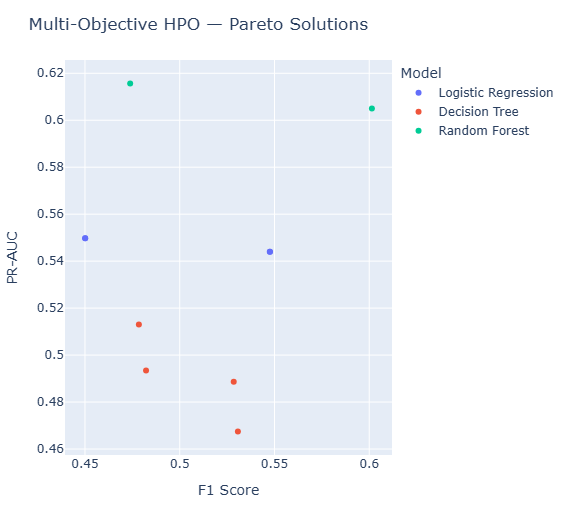

In [27]:
fig = px.scatter(
    pareto_results_df,
    x="F1",
    y="PR_AUC",
    color="Model",
    hover_data=["Trial"],
    title="Multi-Objective HPO — Pareto Solutions",
    labels={
        "F1": "F1 Score",
        "PR_AUC": "PR-AUC",
        "Model": "Model"
    }
)

fig.update_layout(
    width=750,
    height=500,
    margin=dict(
        l=60,
        r=30,
        t=60,
        b=60
    )
)

fig.show()

In [28]:
pareto_results_path = (
    "../results/metrics/"
    "multiobjective_pareto_results.csv"
)

pareto_results_df.to_csv(
    pareto_results_path,
    index=False
)

print("Pareto results saved successfully:")
print(pareto_results_path)

Pareto results saved successfully:
../results/metrics/multiobjective_pareto_results.csv


In [29]:
logistic_trials_df = logistic_mo_study.trials_dataframe()

tree_trials_df = tree_mo_study.trials_dataframe()

rf_trials_df = rf_mo_study.trials_dataframe()

logistic_trials_df.to_csv(
    "../results/hpo/logistic_multiobjective_trials.csv",
    index=False
)

tree_trials_df.to_csv(
    "../results/hpo/decision_tree_multiobjective_trials.csv",
    index=False
)

rf_trials_df.to_csv(
    "../results/hpo/random_forest_multiobjective_trials.csv",
    index=False
)

print("All multi-objective trial histories saved successfully.")

All multi-objective trial histories saved successfully.


In [30]:
print("=" * 80)
print("STAGE 7 TRIAL SUMMARY")
print("=" * 80)

print(
    "\nLogistic Regression:",
    len(logistic_mo_study.trials),
    "trials"
)

print(
    "Decision Tree:",
    len(tree_mo_study.trials),
    "trials"
)

print(
    "Random Forest:",
    len(rf_mo_study.trials),
    "trials"
)

print("\nPareto solutions:")

print(
    "Logistic Regression:",
    len(logistic_mo_study.best_trials)
)

print(
    "Decision Tree:",
    len(tree_mo_study.best_trials)
)

print(
    "Random Forest:",
    len(rf_mo_study.best_trials)
)

STAGE 7 TRIAL SUMMARY

Logistic Regression: 20 trials
Decision Tree: 20 trials
Random Forest: 20 trials

Pareto solutions:
Logistic Regression: 4
Decision Tree: 4
Random Forest: 2


In [31]:
# ============================================================
# CELL 33 — STAGE 7 VALIDATION
# ============================================================

print("=" * 80)
print("STAGE 7 VALIDATION")
print("=" * 80)

# ------------------------------------------------------------
# Check that each study contains trials
# ------------------------------------------------------------

assert len(logistic_mo_study.trials) > 0
assert len(tree_mo_study.trials) > 0
assert len(rf_mo_study.trials) > 0

print("\n✓ All three multi-objective studies contain trials.")


# ------------------------------------------------------------
# Check trial states
# ------------------------------------------------------------

logistic_complete = sum(
    trial.state == optuna.trial.TrialState.COMPLETE
    for trial in logistic_mo_study.trials
)

tree_complete = sum(
    trial.state == optuna.trial.TrialState.COMPLETE
    for trial in tree_mo_study.trials
)

rf_complete = sum(
    trial.state == optuna.trial.TrialState.COMPLETE
    for trial in rf_mo_study.trials
)

print("\nCompleted trials:")
print("Logistic Regression:", logistic_complete)
print("Decision Tree:", tree_complete)
print("Random Forest:", rf_complete)

assert logistic_complete > 0
assert tree_complete > 0
assert rf_complete > 0

print("\n✓ All three models contain completed trials.")


# ------------------------------------------------------------
# Check Pareto solutions
# ------------------------------------------------------------

assert len(logistic_mo_study.best_trials) > 0
assert len(tree_mo_study.best_trials) > 0
assert len(rf_mo_study.best_trials) > 0

print("✓ All three studies produced Pareto-optimal solutions.")


# ------------------------------------------------------------
# Check objective values
# ------------------------------------------------------------

for study in [
    logistic_mo_study,
    tree_mo_study,
    rf_mo_study
]:

    for trial in study.best_trials:

        assert len(trial.values) == 2
        assert trial.values[0] >= 0
        assert trial.values[1] >= 0

print("✓ F1 and PR-AUC objective values are valid.")


# ------------------------------------------------------------
# Check saved results
# ------------------------------------------------------------

assert os.path.exists(
    "../results/metrics/multiobjective_pareto_results.csv"
)

print("✓ Pareto results file exists.")


# ------------------------------------------------------------
# Final message
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("STAGE 7 VALIDATION COMPLETED SUCCESSFULLY")
print("=" * 80)

STAGE 7 VALIDATION

✓ All three multi-objective studies contain trials.

Completed trials:
Logistic Regression: 20
Decision Tree: 20
Random Forest: 20

✓ All three models contain completed trials.
✓ All three studies produced Pareto-optimal solutions.
✓ F1 and PR-AUC objective values are valid.
✓ Pareto results file exists.

STAGE 7 VALIDATION COMPLETED SUCCESSFULLY
